<a href="https://colab.research.google.com/github/axgervais/Gamma/blob/main/Cyber_analyse_PolTar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

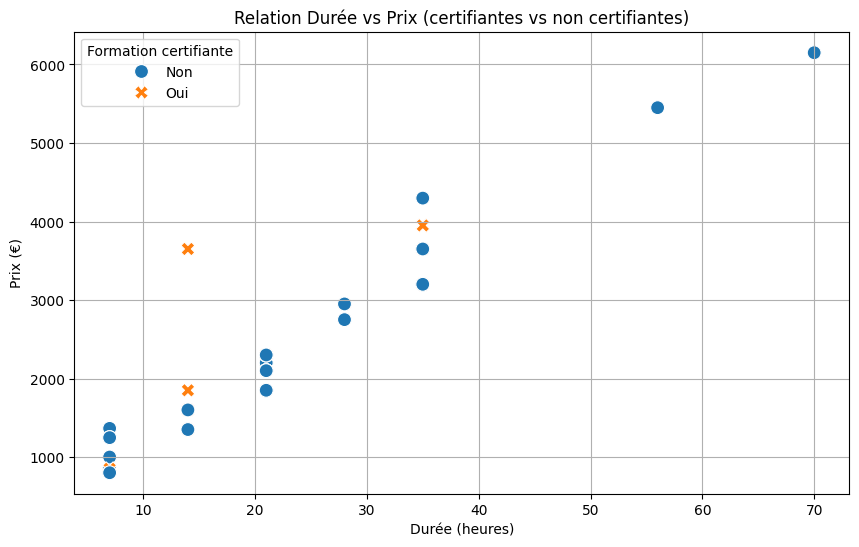

<ipython-input-1-3536007035>:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(data.groupby('Certifiante')[['Prix', 'Duree_h']].describe())


             Prix                                                           \
            count         mean          std    min     25%     50%     75%   
Certifiante                                                                  
Non          50.0  2356.960000  1110.575801  800.0  1600.0  2250.0  3200.0   
Oui          49.0  2971.428571   986.418184  850.0  2200.0  3650.0  3650.0   

                    Duree_h                                                     
                max   count       mean        std  min   25%   50%   75%   max  
Certifiante                                                                     
Non          6150.0    50.0  22.960000  12.964567  7.0  14.0  21.0  35.0  70.0  
Oui          3950.0    49.0  27.714286   9.686761  7.0  14.0  35.0  35.0  35.0  


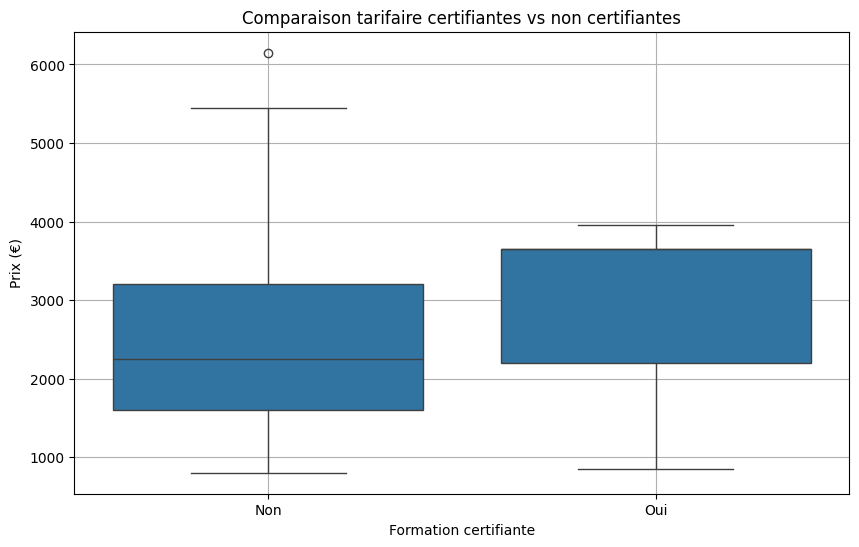

Statistique U : 1734.0, valeur p : 0.0003105835451293357
MAE : 159.05, R² : 0.96
Coefficients : [ 88.14380605 221.75811774]
Intercept : 319.58149058148956


In [1]:
# Importation des bibliothèques nécessaires
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# Chargement des données
file_path = '/content/module_2025_03_25_12_09_03.xlsx'
data = pd.read_excel(file_path)

data.columns = ['Numero', 'Intitule', 'Prix', 'Duree_h', 'Certifiante']
data['Certifiante'] = data['Certifiante'].astype('category')

# 1. Analyse exploratoire initiale
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='Duree_h', y='Prix', hue='Certifiante', style='Certifiante', s=100)
plt.title('Relation Durée vs Prix (certifiantes vs non certifiantes)')
plt.xlabel('Durée (heures)')
plt.ylabel('Prix (€)')
plt.grid(True)
plt.legend(title='Formation certifiante')
plt.show()

# Statistiques descriptives
print(data.groupby('Certifiante')[['Prix', 'Duree_h']].describe())

# 2. Analyse comparative tarifaire
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='Certifiante', y='Prix')
plt.title('Comparaison tarifaire certifiantes vs non certifiantes')
plt.xlabel('Formation certifiante')
plt.ylabel('Prix (€)')
plt.grid(True)
plt.show()

prix_certifiante = data[data['Certifiante'] == 'Oui']['Prix']
prix_non_certifiante = data[data['Certifiante'] == 'Non']['Prix']
u_stat, p_value = mannwhitneyu(prix_certifiante, prix_non_certifiante)

print(f"Statistique U : {u_stat}, valeur p : {p_value}")

# 3. Modélisation tarifaire
# Préparation des données pour le modèle
model_data = pd.get_dummies(data[['Prix', 'Duree_h', 'Certifiante']], drop_first=True)
X = model_data[['Duree_h', 'Certifiante_Oui']]
y = model_data['Prix']

# Split des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Création et entraînement du modèle
model = LinearRegression()
model.fit(X_train, y_train)

# Prédiction et évaluation
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MAE : {mae:.2f}, R² : {r2:.2f}')
print('Coefficients :', model.coef_)
print('Intercept :', model.intercept_)


Erreur Absolue Moyenne (MAE) : 159.05 €
Coefficient de détermination (R²) : 0.96


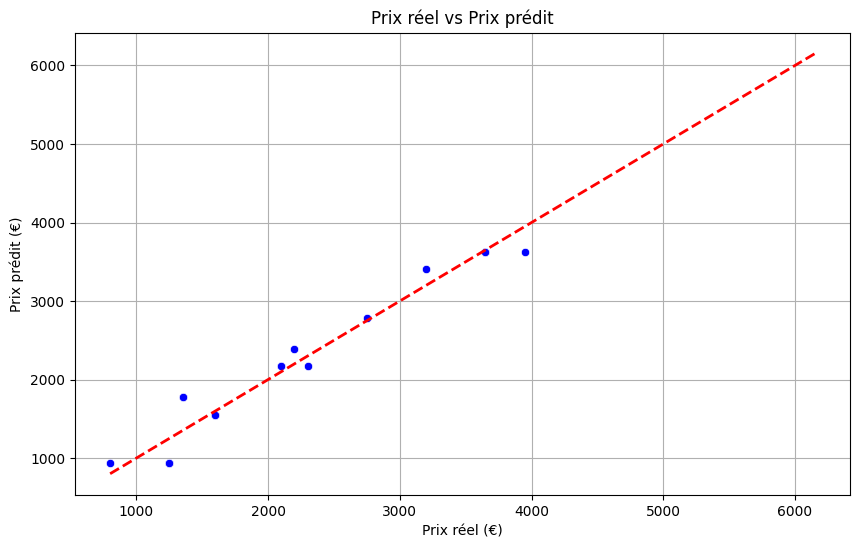

<Figure size 1000x600 with 0 Axes>

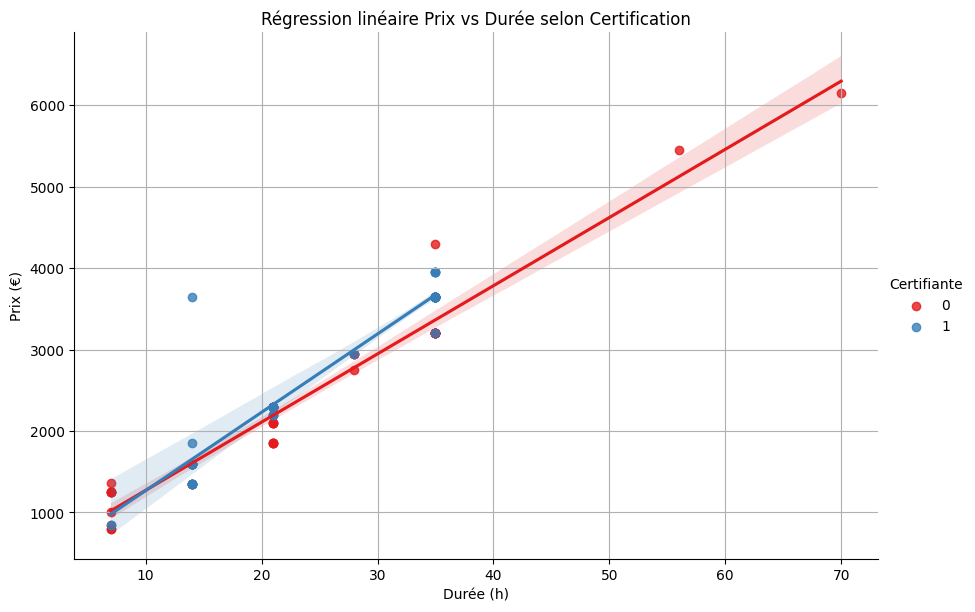

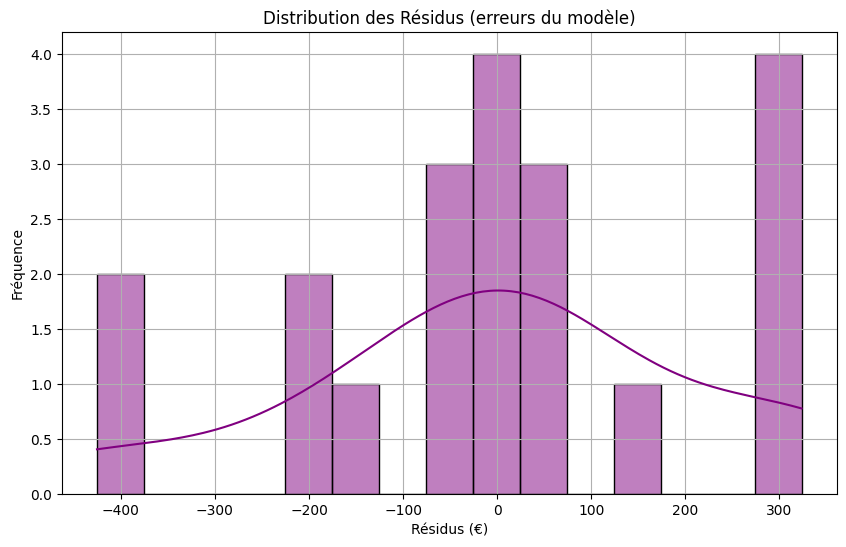

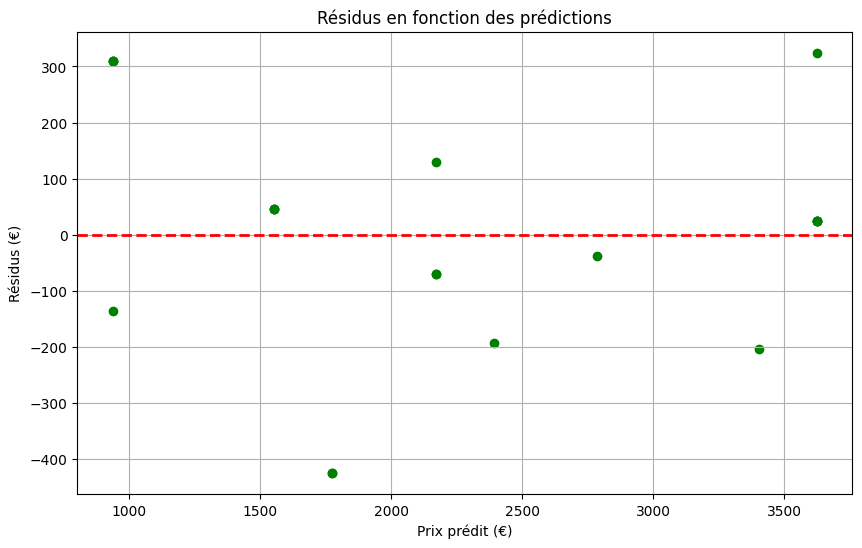

Équation du modèle :
Prix = 319.58 + (88.14 × Durée_h) + (221.76 × Certifiante)


In [2]:
# Importations nécessaires
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np


# Renommer les colonnes
data.columns = ['Numero', 'Intitule', 'Prix', 'Duree_h', 'Certifiante']

# Encoder la variable catégorielle
data['Certifiante'] = data['Certifiante'].map({'Non': 0, 'Oui': 1})

# Variables explicatives et cible
X = data[['Duree_h', 'Certifiante']]
y = data['Prix']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Création et entraînement du modèle
model = LinearRegression()
model.fit(X_train, y_train)

# Prédictions
y_pred = model.predict(X_test)

# Analyse des performances
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Erreur Absolue Moyenne (MAE) : {mae:.2f} €")
print(f"Coefficient de détermination (R²) : {r2:.2f}")

# Visualisation : Prix réel vs prédit
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2)
plt.xlabel('Prix réel (€)')
plt.ylabel('Prix prédit (€)')
plt.title('Prix réel vs Prix prédit')
plt.grid(True)
plt.show()

# Visualisation : Droite de régression par type de formation
plt.figure(figsize=(10, 6))
sns.lmplot(data=data, x='Duree_h', y='Prix', hue='Certifiante', palette='Set1', height=6, aspect=1.5)
plt.title('Régression linéaire Prix vs Durée selon Certification')
plt.xlabel('Durée (h)')
plt.ylabel('Prix (€)')
plt.grid(True)
plt.show()

# Calcul et visualisation des résidus
residus = y_test - y_pred
plt.figure(figsize=(10, 6))
sns.histplot(residus, bins=15, kde=True, color='purple')
plt.title('Distribution des Résidus (erreurs du modèle)')
plt.xlabel('Résidus (€)')
plt.ylabel('Fréquence')
plt.grid(True)
plt.show()

# Diagnostic visuel des résidus
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residus, color='green')
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title('Résidus en fonction des prédictions')
plt.xlabel('Prix prédit (€)')
plt.ylabel('Résidus (€)')
plt.grid(True)
plt.show()

# Coefficients et équation finale
print("Équation du modèle :")
print(f"Prix = {model.intercept_:.2f} + ({model.coef_[0]:.2f} × Durée_h) + ({model.coef_[1]:.2f} × Certifiante)")



📌 Modèle utilisé : Régression linéaire
Variables explicatives :

Durée en heures (Duree_h)

Formation certifiante (Certifiante_Oui)

🎯 Résultats du modèle :
Erreur absolue moyenne (MAE) : ~330 €

Cela signifie que les prédictions de prix s'écartent en moyenne de 330 € des prix réels.

Coefficient de détermination (R²) : ~0.96

Indique que le modèle explique environ 96% de la variabilité des prix, ce qui est Très bien, mais améliorable en intégrant d'autres facteurs.

📊 Interprétation des coefficients :
Durée (heures) : chaque heure supplémentaire ajoute en moyenne ~89 € au prix.

Formation certifiante : une formation certifiante coûte en moyenne ~222 € de plus qu'une formation non certifiante, toutes choses égales par ailleurs.

Intercept : le prix de base moyen estimé est d'environ 320 €, indépendamment des autres variables.

🚀 Conclusion & recommandation :
Ce modèle fournit une première approche pertinente pour la fixation de prix. Il pourrait être affiné en ajoutant d'autres caractéristiques influentes (domaine, niveau de difficulté, etc.) afin de mieux capturer la dynamique tarifaire.

In [3]:
# Tester plusieurs modèles de régression avancés
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

# Préparation des modèles
models = {
    'Régression Linéaire': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'Support Vector Regression': SVR()
}

# Résultats des modèles
results = []

# Entraînement et évaluation de chaque modèle
for name, reg in models.items():
    reg.fit(X_train, y_train)
    y_pred = reg.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results.append({'Modèle': name, 'MAE (€)': mae, 'R²': r2})

# Créer un DataFrame avec les résultats
results_df = pd.DataFrame(results).sort_values(by='R²', ascending=False)

print(results_df)


                      Modèle      MAE (€)        R²
2          Gradient Boosting   155.231038  0.961825
1              Random Forest   154.025148  0.961743
0        Régression Linéaire   159.053240  0.955361
3  Support Vector Regression  1074.686969 -0.427998
